In [16]:
import gzip
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Path to the annotation file
# You can change this to your generated file: 'custom_dataset_generator/output/human_body/frame_annotations.jgz'
# Or an existing one: 'co3d/dataset/multi_view/apple/frame_annotations.jgz'
file_path = 'co3d/dataset/multi_view/backpack/frame_annotations.jgz'

def load_jgz(path):
    with gzip.open(path, 'rt', encoding='utf-8') as f:
        return json.load(f)

if os.path.exists(file_path):
    annotations = load_jgz(file_path)
    print(f"Loaded {len(annotations)} frames from {file_path}")
else:
    print(f"File not found: {file_path}")

Loaded 202 frames from co3d/dataset/multi_view/backpack/frame_annotations.jgz


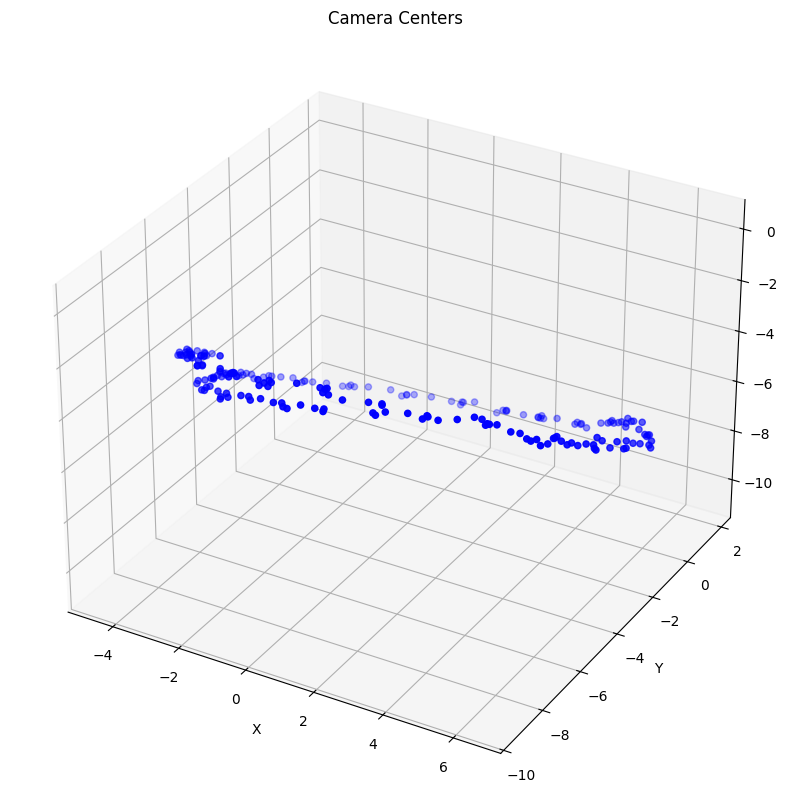

In [17]:
def get_camera_centers(annotations):
    centers = []
    for frame in annotations:
        vp = frame.get('viewpoint')
        if vp:
            R = np.array(vp['R'])
            T = np.array(vp['T'])
            # Camera center in world coordinates: C = -R^T * T
            # In PyTorch3D convention: X_cam = X_world @ R + T
            # So X_world = (X_cam - T) @ R^T
            # Camera center is at X_cam = 0
            # C = -T @ R^T = -(R @ T) if R was column-major, but here R is row-major in the annotation?
            # Wait, data_types.py says: X_cam = X_world @ R + T.
            # So 0 = C @ R + T  =>  C @ R = -T  =>  C = -T @ R^-1 = -T @ R^T
            C = -np.dot(T, R.T)
            centers.append(C)
    return np.array(centers)

if 'annotations' in locals() and annotations:
    centers = get_camera_centers(annotations)
    
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    ax.scatter(centers[:, 0], centers[:, 1], centers[:, 2], c='b', marker='o')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('Camera Centers')
    
    # Set equal aspect ratio for better visualization
    max_range = np.array([centers[:, 0].max()-centers[:, 0].min(), 
                          centers[:, 1].max()-centers[:, 1].min(), 
                          centers[:, 2].max()-centers[:, 2].min()]).max() / 2.0
    mid_x = (centers[:, 0].max()+centers[:, 0].min()) * 0.5
    mid_y = (centers[:, 1].max()+centers[:, 1].min()) * 0.5
    mid_z = (centers[:, 2].max()+centers[:, 2].min()) * 0.5
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)
    
    plt.show()

In [18]:
if 'annotations' in locals() and annotations:
    print("First frame annotation:")
    print(json.dumps(annotations[0], indent=2))

First frame annotation:
{
  "sequence_name": "537_78249_152122",
  "frame_number": 6,
  "frame_timestamp": 0.9477611940298508,
  "image": {
    "path": "backpack/537_78249_152122/images/frame000006.jpg",
    "size": [
      1215,
      683
    ]
  },
  "depth": {
    "path": "backpack/537_78249_152122/depths/frame000006.jpg.geometric.png",
    "scale_adjustment": 1.0,
    "mask_path": "backpack/537_78249_152122/depth_masks/frame000006.png"
  },
  "mask": {
    "path": "backpack/537_78249_152122/masks/frame000006.png",
    "mass": 1000000
  },
  "viewpoint": {
    "R": [
      [
        0.9661634564399719,
        0.2451031357049942,
        -0.08032841235399246
      ],
      [
        0.002970687812194228,
        0.30083927512168884,
        0.9536702036857605
      ],
      [
        0.2579135000705719,
        -0.9216399192810059,
        0.2899317741394043
      ]
    ],
    "T": [
      0.09310286492109299,
      0.7132307887077332,
      9.11965560913086
    ],
    "focal_length

In [19]:
# Verification of R matrix convention (Row-major vs Column-major)
# In PyTorch3D (and CO3D), the convention is: X_cam = X_world @ R + T
# This implies R is used for right-multiplication.
# Let's verify if R is orthogonal (R @ R.T should be Identity).
# If R is a valid rotation matrix, its determinant should be 1.

if 'annotations' in locals() and annotations:
    vp = annotations[0]['viewpoint']
    R = np.array(vp['R'])
    
    print("Rotation Matrix R:")
    print(R)
    
    print("\nCheck Orthogonality (R @ R.T):")
    print(np.round(R @ R.T, 6))
    
    print("\nDeterminant:")
    print(np.linalg.det(R))
    
    # To check if it's row-major or column-major relative to the transformation logic:
    # If X_cam = X_world @ R + T, then:
    # R[0, :] is the direction of World X axis in Camera coordinates.
    # R[1, :] is the direction of World Y axis in Camera coordinates.
    # R[2, :] is the direction of World Z axis in Camera coordinates.
    
    # Let's look at the Up vector (World Y).
    # In many CO3D sequences, the object is upright in World Y.
    # If the camera is looking at the object from the side, the World Y axis should project 
    # mostly to the Camera Y axis (if upright) or -Y axis (if inverted).
    
    print("\nWorld Y axis in Camera Frame (Row 1 of R):", R[1, :])
    
    # If R was column-major (meaning X_cam = R @ X_world + T), then:
    # R[:, 1] would be the World Y axis in Camera coordinates.
    print("World Y axis in Camera Frame (Column 1 of R):", R[:, 1])
    
    print("\nInterpretation:")
    print("If 'Row 1' looks like a unit vector pointing Up/Down in the camera view (e.g., [0, 1, 0] or [0, -1, 0]),")
    print("then R is likely Row-major (Right-multiply convention).")

Rotation Matrix R:
[[ 0.96616346  0.24510314 -0.08032841]
 [ 0.00297069  0.30083928  0.9536702 ]
 [ 0.2579135  -0.92163992  0.28993177]]

Check Orthogonality (R @ R.T):
[[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]

Determinant:
0.9999999626751004

World Y axis in Camera Frame (Row 1 of R): [0.00297069 0.30083928 0.9536702 ]
World Y axis in Camera Frame (Column 1 of R): [ 0.24510314  0.30083928 -0.92163992]

Interpretation:
If 'Row 1' looks like a unit vector pointing Up/Down in the camera view (e.g., [0, 1, 0] or [0, -1, 0]),
then R is likely Row-major (Right-multiply convention).


In [20]:
if 'annotations' in locals() and annotations:
    # We look at a few frames to be sure, in case one camera is upside down
    y_projections = []
    # Check up to 10 frames
    num_frames_to_check = min(10, len(annotations))
    for i in range(num_frames_to_check):
        vp = annotations[i].get('viewpoint')
        if vp:
            R_check = np.array(vp['R'])
            # R[1, 1] represents how much of World Y maps to Camera Y
            # Row 1 is World Y axis in Camera Frame. Element 1 is the Y component.
            y_projections.append(R_check[1, 1])
    
    if y_projections:
        avg_y_proj = np.mean(y_projections)
        
        print(f"Average Y-to-Y projection (R[1,1]): {avg_y_proj:.4f}")
        
        if avg_y_proj > 0.5:
            print(">> CONCLUSION: PyTorch3D Convention (+Y is Up)")
            print("   (World Y aligns with Camera Y)")
        elif avg_y_proj < -0.5:
            print(">> CONCLUSION: OpenCV Convention (+Y is Down)")
            print("   (World Y opposes Camera Y)")
        else:
            print(">> CONCLUSION: Inconclusive (Cameras might be heavily tilted or World Y is not Up)")
    else:
        print("No viewpoint information found in the first few frames.")

Average Y-to-Y projection (R[1,1]): 0.2204
>> CONCLUSION: Inconclusive (Cameras might be heavily tilted or World Y is not Up)


In [21]:
# Verification of Forward Axis Convention (+Z vs -Z)
# We calculate the dot product between the Camera Z-axis (from R) and the Vector-to-Origin.
# Vector-to-Origin V = Origin - Camera_Center = -C
# Camera Z-axis (in World Frame) is the 3rd column of the Camera-to-World Rotation Matrix.
# Since stored R is Row-Major World-to-Camera, R_c2w = R.T (if we treat R as column-major logic) or just R (if we treat R as row-major logic).
# Let's stick to the definition: X_cam = X_world @ R + T
# Row 2 of R is the World Z-axis in Camera Frame.
# Column 2 of R is the Camera Z-axis in World Frame.

if 'annotations' in locals() and annotations:
    z_dots = []
    num_frames_to_check = min(10, len(annotations))
    
    for i in range(num_frames_to_check):
        vp = annotations[i].get('viewpoint')
        if not vp: continue
            
        R = np.array(vp['R'])
        T = np.array(vp['T'])
        
        # Camera Center C = -T @ R^T
        C = -np.dot(T, R.T)
        
        # Vector from Camera to Origin (assuming object is at origin)
        V = -C
        dist = np.linalg.norm(V)
        if dist < 1e-6: continue
        V_norm = V / dist
        
        # Camera Z-axis in World Frame
        # In X_cam = X_world @ R + T:
        # R's columns are the Camera axes expressed in World Frame? 
        # Let's derive:
        # [1, 0, 0]_cam = [r00, r10, r20]_world (Column 0 of R)
        # [0, 1, 0]_cam = [r01, r11, r21]_world (Column 1 of R)
        # [0, 0, 1]_cam = [r02, r12, r22]_world (Column 2 of R)
        # So Column 2 is the Camera Z-axis direction in World coordinates.
        CamZ_world = R[:, 2]
        
        dot_prod = np.dot(CamZ_world, V_norm)
        z_dots.append(dot_prod)
        
    if z_dots:
        avg_z_dot = np.mean(z_dots)
        print(f"Average Dot Product (Camera Z-axis vs Vector-to-Origin): {avg_z_dot:.4f}")
        
        if avg_z_dot > 0.8:
            print(">> CONCLUSION: +Z is Forward (OpenCV / PyTorch3D)")
            print("   (Camera Z points TOWARDS the object)")
        elif avg_z_dot < -0.8:
            print(">> CONCLUSION: -Z is Forward (OpenGL)")
            print("   (Camera Z points AWAY from the object)")
        else:
            print(">> CONCLUSION: Inconclusive (Camera might not be looking at origin)")


Average Dot Product (Camera Z-axis vs Vector-to-Origin): 0.9972
>> CONCLUSION: +Z is Forward (OpenCV / PyTorch3D)
   (Camera Z points TOWARDS the object)


Plotting every 10th camera...


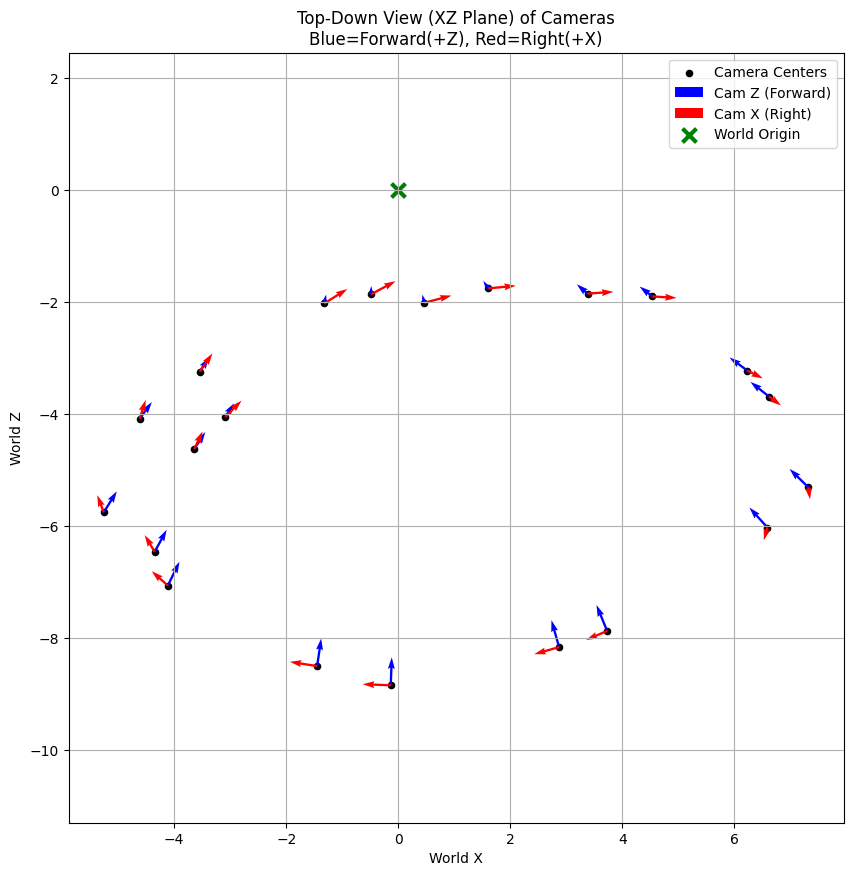

In [22]:
if 'annotations' in locals() and annotations:
    # Re-calculate centers and axes
    centers_x = []
    centers_z = []
    
    cam_x_dirs = [] # Camera X axis direction in World
    cam_z_dirs = [] # Camera Z axis direction in World
    
    # Use a stride to avoid overcrowding the plot if there are many frames
    stride = 10
    
    print(f"Plotting every {stride}th camera...")
    
    for i in range(0, len(annotations), stride):
        vp = annotations[i].get('viewpoint')
        if vp:
            R = np.array(vp['R'])
            T = np.array(vp['T'])
            
            # Center C = -T @ R^T
            C = -T @ R.T
            
            centers_x.append(C[0])
            centers_z.append(C[2])
            
            # Camera axes in World Frame are columns of R
            # Cam X axis = Column 0
            cam_x_dirs.append(R[:, 0])
            # Cam Z axis = Column 2
            cam_z_dirs.append(R[:, 2])
            
    centers_x = np.array(centers_x)
    centers_z = np.array(centers_z)
    cam_x_dirs = np.array(cam_x_dirs)
    cam_z_dirs = np.array(cam_z_dirs)
    
    plt.figure(figsize=(10, 10))
    
    # Plot Centers
    plt.scatter(centers_x, centers_z, c='black', marker='o', s=20, label='Camera Centers')
    
    # Plot Camera Z axes (Forward) - Blue
    # Scale arrows for visibility. Adjust 'scale' as needed based on scene size (usually ~1-3 units)
    arrow_len = 0.5
    plt.quiver(centers_x, centers_z, 
               cam_z_dirs[:, 0], cam_z_dirs[:, 2], 
               color='blue', scale=1.0/arrow_len, scale_units='xy', angles='xy', width=0.003, label='Cam Z (Forward)')
               
    # Plot Camera X axes (Right) - Red
    plt.quiver(centers_x, centers_z, 
               cam_x_dirs[:, 0], cam_x_dirs[:, 2], 
               color='red', scale=1.0/arrow_len, scale_units='xy', angles='xy', width=0.003, label='Cam X (Right)')
    
    # Plot Origin
    plt.scatter([0], [0], c='green', marker='x', s=100, linewidths=3, label='World Origin')
    
    plt.xlabel('World X')
    plt.ylabel('World Z')
    plt.title('Top-Down View (XZ Plane) of Cameras\nBlue=Forward(+Z), Red=Right(+X)')
    plt.legend()
    plt.axis('equal')
    plt.grid(True)
    plt.show()

Total Cameras: 202
Average Camera Y height: -4.2887
Min Camera Y: -8.9653
Max Camera Y: 1.3696
Count Negative Y: 167
Count Positive Y: 35

>> CONCLUSION: Cameras are mostly at NEGATIVE Y.
   If cameras are 'above' the object, this implies World Y points DOWN.


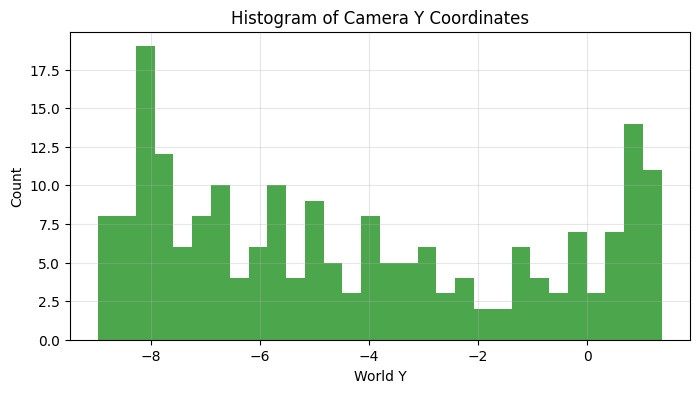

In [23]:
# Verification of World Y Axis Direction
# If the object is at the origin (0,0,0) and the cameras are "above" it looking down:
# - If World Y is UP (+Y), Camera Y should be POSITIVE.
# - If World Y is DOWN (+Y), Camera Y should be NEGATIVE.

if 'annotations' in locals() and annotations:
    centers_y = []
    for frame in annotations:
        vp = frame.get('viewpoint')
        if vp:
            R = np.array(vp['R'])
            T = np.array(vp['T'])
            # Calculate Center
            C = -T @ R.T
            centers_y.append(C[1])
            
    centers_y = np.array(centers_y)
    
    print(f"Total Cameras: {len(centers_y)}")
    print(f"Average Camera Y height: {np.mean(centers_y):.4f}")
    print(f"Min Camera Y: {np.min(centers_y):.4f}")
    print(f"Max Camera Y: {np.max(centers_y):.4f}")
    
    num_neg = np.sum(centers_y < 0)
    num_pos = np.sum(centers_y > 0)
    
    print(f"Count Negative Y: {num_neg}")
    print(f"Count Positive Y: {num_pos}")
    
    if num_neg > num_pos:
        print("\n>> CONCLUSION: Cameras are mostly at NEGATIVE Y.")
        print("   If cameras are 'above' the object, this implies World Y points DOWN.")
    else:
        print("\n>> CONCLUSION: Cameras are mostly at POSITIVE Y.")
        print("   If cameras are 'above' the object, this implies World Y points UP.")
        
    # Plot histogram of Y values
    plt.figure(figsize=(8, 4))
    plt.hist(centers_y, bins=30, color='green', alpha=0.7)
    plt.title("Histogram of Camera Y Coordinates")
    plt.xlabel("World Y")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    plt.show()

In [24]:
# Check Scale of Camera Parameters
# We calculate the average distance of cameras from the origin (or centroid of cameras).
# This gives us an idea of the scene scale (e.g., is it ~1.0, ~100.0, or ~1000.0?)

if 'annotations' in locals() and annotations:
    centers = []
    for frame in annotations:
        vp = frame.get('viewpoint')
        if vp:
            R = np.array(vp['R'])
            T = np.array(vp['T'])
            # C = -T @ R.T
            C = -np.dot(T, R.T)
            centers.append(C)
            
    centers = np.array(centers)
    
    # Calculate centroid of cameras
    centroid = np.mean(centers, axis=0)
    
    # Calculate distances from centroid
    dists = np.linalg.norm(centers - centroid, axis=1)
    
    avg_dist = np.mean(dists)
    min_dist = np.min(dists)
    max_dist = np.max(dists)
    
    print(f"Camera Centroid: {np.round(centroid, 4)}")
    print(f"Average Distance from Centroid: {avg_dist:.4f}")
    print(f"Min Distance: {min_dist:.4f}")
    print(f"Max Distance: {max_dist:.4f}")
    
    print("\nInterpretation:")
    if avg_dist < 10.0:
        print("- Scale likely METERS (or normalized unit sphere).")
    elif avg_dist > 100.0:
        print("- Scale likely MILLIMETERS or CENTIMETERS.")
    else:
        print("- Scale is ambiguous (could be decimeters or large objects in meters).")
        
    # Also check translation vector magnitude directly
    # T represents the World Origin in the Camera Frame.
    # If object is at World Origin, |T| is the distance to the object.
    Ts = []
    for frame in annotations:
        vp = frame.get('viewpoint')
        if vp:
            Ts.append(np.linalg.norm(vp['T']))
            
    avg_T_norm = np.mean(Ts)
    print(f"\nAverage |T| (Distance to World Origin): {avg_T_norm:.4f}")

Camera Centroid: [ 0.5114 -4.2887 -4.7551]
Average Distance from Centroid: 5.7915
Min Distance: 4.3681
Max Distance: 7.1038

Interpretation:
- Scale likely METERS (or normalized unit sphere).

Average |T| (Distance to World Origin): 8.6783


In [25]:
# Check Depth Maps
# We will load and visualize the depth map for the first frame.
# We also check the min/max values to understand the depth scale.

if 'annotations' in locals() and annotations:
    import cv2
    
    # Get the first frame
    frame = annotations[0]
    depth_info = frame.get('depth')
    
    if depth_info:
        depth_path_rel = depth_info['path']
        scale_adjustment = depth_info['scale_adjustment']
        
        # Construct absolute path
        # Assuming the notebook is in the root, and paths are relative to the dataset root
        # Adjust base_path if needed. For custom dataset: 'custom_dataset_generator/output'
        # For CO3D dataset: 'co3d/dataset'
        
        # Try to find the file
        base_paths = ['co3d/dataset/multi_view/bicycle', 'co3d/dataset', '.']
        depth_path_abs = None
        
        for base in base_paths:
            p = os.path.join(base, depth_path_rel)
            if os.path.exists(p):
                depth_path_abs = p
                break
                
        if depth_path_abs:
            print(f"Loading depth from: {depth_path_abs}")
            
            # Load depth image (16-bit PNG)
            depth_img = cv2.imread(depth_path_abs, cv2.IMREAD_ANYDEPTH)
            
            if depth_img is not None:
                # Convert to float and apply scale
                depth_meters = depth_img.astype(np.float32) * scale_adjustment
                
                print(f"Depth Image Shape: {depth_img.shape}")
                print(f"Depth Data Type: {depth_img.dtype}")
                print(f"Scale Adjustment: {scale_adjustment}")
                print(f"Min Depth (m): {np.min(depth_meters):.4f}")
                print(f"Max Depth (m): {np.max(depth_meters):.4f}")
                print(f"Mean Depth (m): {np.mean(depth_meters):.4f}")
                
                # Visualize
                plt.figure(figsize=(10, 5))
                
                plt.subplot(1, 2, 1)
                plt.imshow(depth_meters, cmap='plasma')
                plt.colorbar(label='Depth (m)')
                plt.title(f"Depth Map (Frame {frame['frame_number']})")
                
                # Histogram
                plt.subplot(1, 2, 2)
                plt.hist(depth_meters.flatten(), bins=50, color='blue', alpha=0.7)
                plt.title("Depth Distribution")
                plt.xlabel("Depth (m)")
                plt.ylabel("Pixel Count")
                
                plt.tight_layout()
                plt.show()
            else:
                print("Failed to load depth image with cv2.")
        else:
            print(f"Depth file not found: {depth_path_rel}")
    else:
        print("No depth info in annotation.")

Depth file not found: backpack/537_78249_152122/depths/frame000006.jpg.geometric.png


In [26]:
depth_info

{'path': 'backpack/537_78249_152122/depths/frame000006.jpg.geometric.png',
 'scale_adjustment': 1.0,
 'mask_path': 'backpack/537_78249_152122/depth_masks/frame000006.png'}

Depth Map Stats:
  Raw Min/Max: 0, 0
  Scale Adjustment: 1.0
  Metric Min/Max: 0.0000, 0.0000


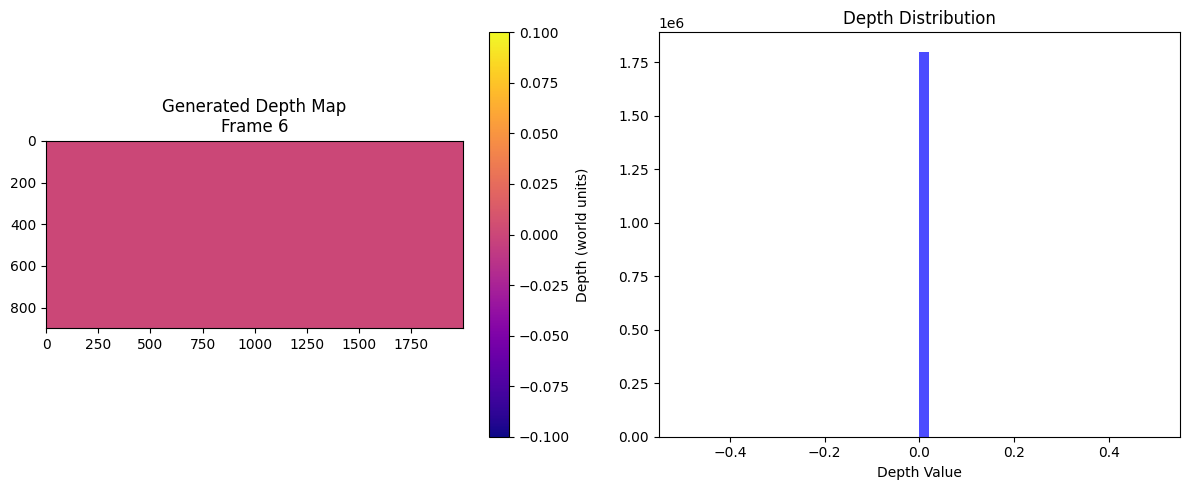

In [27]:
# Cell to verify generated depth maps
# This mimics the logic in JsonIndexDataset: depth = raw_png_value * scale_adjustment

import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

# Path to your generated annotations
generated_annotations_path = 'co3d/dataset/multi_view/apple/frame_annotations.jgz'
dataset_root = 'co3d/dataset/multi_view/'

if os.path.exists(generated_annotations_path):
    annotations = load_jgz(generated_annotations_path)
    
    # Pick the first frame
    frame = annotations[0]
    depth_anno = frame.get('depth')
    
    if depth_anno:
        depth_rel_path = depth_anno['path']
        scale_adjustment = depth_anno['scale_adjustment']
        
        full_depth_path = os.path.join(dataset_root, depth_rel_path)
        
        if os.path.exists(full_depth_path):
            # Load 16-bit PNG
            # cv2.IMREAD_ANYDEPTH is required to load 16-bit images correctly
            depth_raw = cv2.imread(full_depth_path, cv2.IMREAD_ANYDEPTH)
            
            if depth_raw is not None:
                # Apply scale adjustment to get metric depth
                depth_metric = depth_raw.astype(np.float32) * scale_adjustment
                
                print(f"Depth Map Stats:")
                print(f"  Raw Min/Max: {depth_raw.min()}, {depth_raw.max()}")
                print(f"  Scale Adjustment: {scale_adjustment}")
                print(f"  Metric Min/Max: {depth_metric.min():.4f}, {depth_metric.max():.4f}")
                
                # Visualize
                plt.figure(figsize=(12, 5))
                
                plt.subplot(1, 2, 1)
                plt.imshow(depth_metric, cmap='plasma')
                plt.colorbar(label='Depth (world units)')
                plt.title(f"Generated Depth Map\nFrame {frame['frame_number']}")
                
                plt.subplot(1, 2, 2)
                plt.hist(depth_metric.flatten(), bins=50, color='blue', alpha=0.7)
                plt.title("Depth Distribution")
                plt.xlabel("Depth Value")
                
                plt.tight_layout()
                plt.show()
            else:
                print(f"Failed to load image with cv2: {full_depth_path}")
        else:
            print(f"Depth file not found: {full_depth_path}")
    else:
        print("No depth annotation found in this frame.")
else:
    print(f"Annotations file not found: {generated_annotations_path}")

In [39]:
import os
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Use the annotations already loaded for the 'car' category
if 'annotations' in locals() and annotations and category == 'car':
    print("Starting diagnostic for 'car' category...")
    
    # Get the absolute path to the project directory
    project_root = os.path.abspath(os.path.join(dataset_root, '..', '..'))
    print(f"Assuming Project Root: {project_root}")

    target_path_abs = None
    target_frame_info = None
    
    # Find the first file that actually exists on disk
    print("Searching for the first existing depth file in annotations...")
    for i, frame in enumerate(annotations):
        if 'depth' in frame and frame['depth'] is not None:
            # Path from annotation is relative to dataset root, e.g., 'car/sequence/depth/frame.png'
            relative_path = frame['depth']['path']
            # We construct the path from the project root to be safe
            # project_root/co3d/dataset/multi_view/car/sequence/depth/frame.png
            p = os.path.join(project_root, 'co3d', 'dataset', 'multi_view', relative_path)
            
            if os.path.exists(p):
                target_path_abs = p
                target_frame_info = frame
                print(f"Found a file that exists on disk at index {i}!")
                break
    
    if target_path_abs:
        print(f"\n--- Diagnosing File ---")
        print(f"Path: {target_path_abs}")
        print(f"From Sequence: {target_frame_info['sequence_name']}")
        
        # 1. Check File Size
        size_bytes = os.path.getsize(target_path_abs)
        print(f"File Size: {size_bytes} bytes")
        if size_bytes < 1000:
            print("WARNING: File size is very small, it might be an empty or corrupted file.")

        # 2. Load with PIL (Pillow)
        print("\n--- Attempting to load with PIL ---")
        try:
            with Image.open(target_path_abs) as pil_img:
                print(f"PIL Mode: {pil_img.mode} (I;16 is 16-bit integer, good!)")
                pil_data = np.array(pil_img)
                print(f"Data Type: {pil_data.dtype}")
                print(f"Min/Max Values: {pil_data.min()}, {pil_data.max()}")
                
                if pil_data.max() > 0:
                    print("SUCCESS: PIL loaded non-zero data.")
                    plt.figure(figsize=(6,4))
                    plt.imshow(pil_data, cmap='plasma')
                    plt.title(f"PIL Load (Max Value: {pil_data.max()})")
                    plt.colorbar()
                    plt.show()
                else:
                    print("FAILURE: PIL loaded an all-zero image.")
        except Exception as e:
            print(f"PIL Load FAILED with error: {e}")

        # 3. Load with OpenCV
        print("\n--- Attempting to load with OpenCV ---")
        try:
            # IMREAD_UNCHANGED is the most robust flag for 16-bit data
            cv_img = cv2.imread(target_path_abs, cv2.IMREAD_UNCHANGED)
            if cv_img is not None:
                print(f"Data Type: {cv_img.dtype}")
                print(f"Min/Max Values: {cv_img.min()}, {cv_img.max()}")
                if cv_img.max() > 0:
                    print("SUCCESS: OpenCV loaded non-zero data.")
                else:
                    print("FAILURE: OpenCV loaded an all-zero image.")
            else:
                print("FAILURE: cv2.imread returned None.")
        except Exception as e:
            print(f"OpenCV Load FAILED with error: {e}")

    else:
        print("\nDIAGNOSIS: FAILED. Could not find ANY depth file on disk for the 'car' category using the provided paths.")
        print("This strongly suggests an issue with the dataset path or the files are missing.")
else:
    print("Please ensure the previous cell for the 'car' category has been run successfully.")

Starting diagnostic for 'car' category...
Assuming Project Root: d:\GitHub\co3d\co3d
Searching for the first existing depth file in annotations...

DIAGNOSIS: FAILED. Could not find ANY depth file on disk for the 'car' category using the provided paths.
This strongly suggests an issue with the dataset path or the files are missing.


In [40]:
annotations

[{'sequence_name': '621_101777_202473',
  'frame_number': 6,
  'frame_timestamp': 1.0335820895522387,
  'image': {'path': 'car/621_101777_202473/images/frame000006.jpg',
   'size': [1054, 1875]},
  'depth': {'path': 'car/621_101777_202473/depths/frame000006.jpg.geometric.png',
   'scale_adjustment': 1.0,
   'mask_path': 'car/621_101777_202473/depth_masks/frame000006.png'},
  'mask': {'path': 'car/621_101777_202473/masks/frame000006.png',
   'mass': 1000000},
  'viewpoint': {'R': [[-0.9999859929084778,
     0.0005156566039659083,
     -0.005264845211058855],
    [-0.0005129565834067762, -0.9999997615814209, -0.0005141784204170108],
    [-0.0052651092410087585, -0.0005114706000313163, 0.9999859929084778]],
   'T': [-0.2045934945344925, -0.18358147144317627, 4.670550346374512],
   'focal_length': [2.869753837585449, 2.869753837585449],
   'principal_point': [0.0009487665956839919, 0.0009487665956839919],
   'intrinsics_format': 'ndc_isotropic'},
  'meta': {'frame_type': 'test_unseen',
   

Loading depth maps from annotations...
Found 202 frames with depth annotations

Loading depth from: co3d/dataset/multi_view\car/621_101777_202473/depths/frame000006.jpg.geometric.png
Frame index: 0
Sequence: 621_101777_202473
Frame number: 6

Depth Map Statistics:
  Shape: (1054, 1875)
  Raw Min/Max: 0.0000, 0.0000
  Scale Adjustment: 1.0
  Scaled Min/Max: 0.0000, 0.0000
  Mean Depth: 0.0000


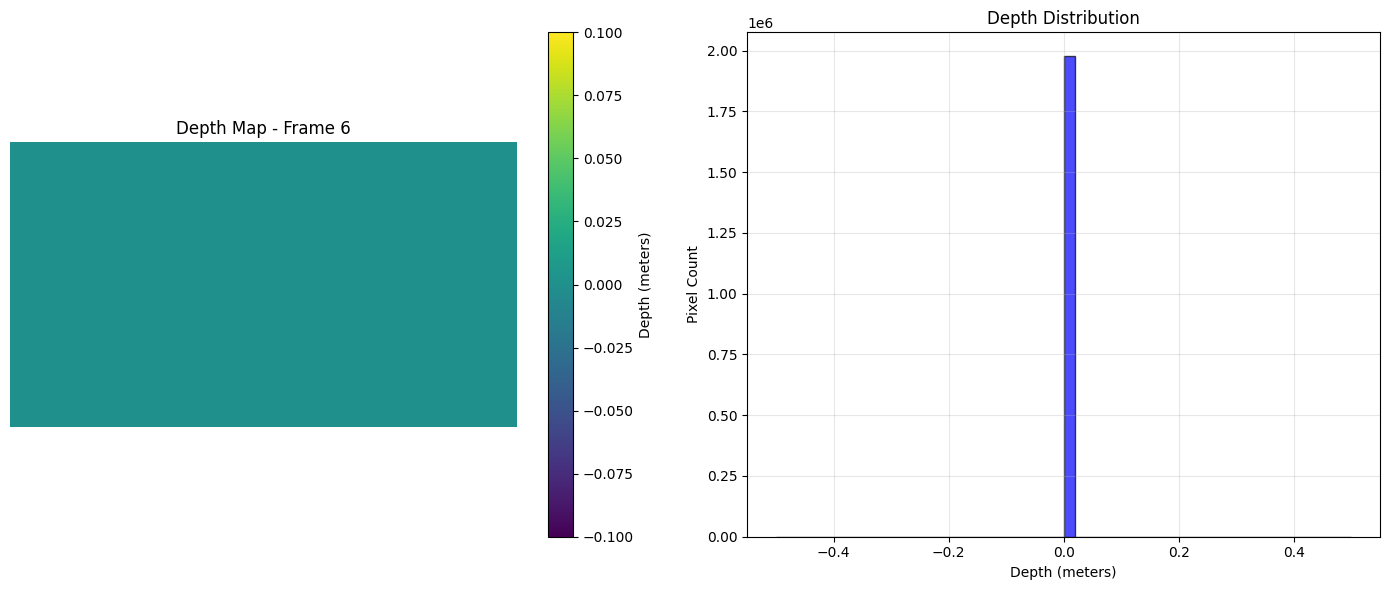

In [41]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def load_16big_png_depth(depth_png: str) -> np.ndarray:
    """
    Loads a 16-bit PNG as a half-float depth map (H, W), returning a float32 NumPy array.

    Implementation detail:
      - PIL loads 16-bit data as 32-bit "I" mode.
      - We reinterpret the bits as float16, then cast to float32.

    Args:
        depth_png (str):
            File path to the 16-bit PNG.

    Returns:
        np.ndarray:
            A float32 depth array of shape (H, W).
    """
    with Image.open(depth_png) as depth_pil:
        depth = (
            np.frombuffer(np.array(depth_pil, dtype=np.uint16), dtype=np.float16)
            .astype(np.float32)
            .reshape((depth_pil.size[1], depth_pil.size[0]))
        )
    return depth

# Load depth maps from the currently loaded annotations
if 'annotations' in locals() and annotations:
    print(f"Loading depth maps from annotations...")
    
    # Find all frames with valid depth annotations
    valid_depth_frames = []
    for i, frame in enumerate(annotations):
        depth_info = frame.get('depth')
        if depth_info and 'path' in depth_info:
            valid_depth_frames.append((i, frame))
    
    print(f"Found {len(valid_depth_frames)} frames with depth annotations")
    
    if valid_depth_frames:
        # Load the first valid depth map
        idx, frame = valid_depth_frames[0]
        depth_rel_path = frame['depth']['path']
        scale_adjustment = frame['depth']['scale_adjustment']
        
        # Construct full path
        depth_full_path = os.path.join('co3d/dataset/multi_view', depth_rel_path)
        
        if os.path.exists(depth_full_path):
            print(f"\nLoading depth from: {depth_full_path}")
            print(f"Frame index: {idx}")
            print(f"Sequence: {frame['sequence_name']}")
            print(f"Frame number: {frame['frame_number']}")
            
            # Load using the custom float16 function
            depth_map = load_16big_png_depth(depth_full_path)
            
            # Apply scale adjustment
            depth_scaled = depth_map * scale_adjustment
            
            print(f"\nDepth Map Statistics:")
            print(f"  Shape: {depth_map.shape}")
            print(f"  Raw Min/Max: {depth_map.min():.4f}, {depth_map.max():.4f}")
            print(f"  Scale Adjustment: {scale_adjustment}")
            print(f"  Scaled Min/Max: {depth_scaled.min():.4f}, {depth_scaled.max():.4f}")
            print(f"  Mean Depth: {depth_scaled.mean():.4f}")
            
            # Visualize
            fig, axes = plt.subplots(1, 2, figsize=(14, 6))
            
            # Depth map
            im = axes[0].imshow(depth_scaled, cmap='viridis')
            axes[0].set_title(f"Depth Map - Frame {frame['frame_number']}")
            axes[0].axis('off')
            plt.colorbar(im, ax=axes[0], label='Depth (meters)')
            
            # Histogram
            axes[1].hist(depth_scaled.flatten(), bins=50, color='blue', alpha=0.7, edgecolor='black')
            axes[1].set_title("Depth Distribution")
            axes[1].set_xlabel("Depth (meters)")
            axes[1].set_ylabel("Pixel Count")
            axes[1].grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
            
        else:
            print(f"Depth file not found: {depth_full_path}")
    else:
        print("No frames with depth annotations found")
else:
    print("Please load annotations first by running the first cell")

In [42]:
annotations

[{'sequence_name': '621_101777_202473',
  'frame_number': 6,
  'frame_timestamp': 1.0335820895522387,
  'image': {'path': 'car/621_101777_202473/images/frame000006.jpg',
   'size': [1054, 1875]},
  'depth': {'path': 'car/621_101777_202473/depths/frame000006.jpg.geometric.png',
   'scale_adjustment': 1.0,
   'mask_path': 'car/621_101777_202473/depth_masks/frame000006.png'},
  'mask': {'path': 'car/621_101777_202473/masks/frame000006.png',
   'mass': 1000000},
  'viewpoint': {'R': [[-0.9999859929084778,
     0.0005156566039659083,
     -0.005264845211058855],
    [-0.0005129565834067762, -0.9999997615814209, -0.0005141784204170108],
    [-0.0052651092410087585, -0.0005114706000313163, 0.9999859929084778]],
   'T': [-0.2045934945344925, -0.18358147144317627, 4.670550346374512],
   'focal_length': [2.869753837585449, 2.869753837585449],
   'principal_point': [0.0009487665956839919, 0.0009487665956839919],
   'intrinsics_format': 'ndc_isotropic'},
  'meta': {'frame_type': 'test_unseen',
   

In [ ]:
import os
import numpy as np
from PIL import Image

def load_16big_png_depth(depth_png: str) -> np.ndarray:
    """
    Loads a 16-bit PNG as a half-float depth map (H, W), returning a float32 NumPy array.
    """
    with Image.open(depth_png) as depth_pil:
        depth = (
            np.frombuffer(np.array(depth_pil, dtype=np.uint16), dtype=np.float16)
            .astype(np.float32)
            .reshape((depth_pil.size[1], depth_pil.size[0]))
        )
    return depth

# Find all frames with non-zero depth values
if 'annotations' in locals() and annotations:
    print(f"Scanning {len(annotations)} frames for valid depth data...")
    print("This may take a moment...\n")
    
    valid_depth_indices = []
    
    for i, frame in enumerate(annotations):
        depth_info = frame.get('depth')
        
        if depth_info and 'path' in depth_info:
            depth_rel_path = depth_info['path']
            depth_full_path = os.path.join('co3d/dataset/multi_view', depth_rel_path)
            
            if os.path.exists(depth_full_path):
                try:
                    # Load depth map
                    depth_map = load_16big_png_depth(depth_full_path)
                    
                    # Check if it has non-zero values
                    if depth_map.max() > 0:
                        valid_depth_indices.append(i)
                        
                        # Print first few valid ones
                        if len(valid_depth_indices) <= 5:
                            print(f"✓ Frame {i}: Sequence '{frame['sequence_name']}', "
                                  f"Frame #{frame['frame_number']}, "
                                  f"Max Depth: {depth_map.max():.2f}")
                
                except Exception as e:
                    # Silently skip problematic files
                    pass
        
        # Progress indicator every 50 frames
        if (i + 1) % 50 == 0:
            print(f"  Processed {i + 1}/{len(annotations)} frames... "
                  f"Found {len(valid_depth_indices)} valid so far")
    
    print(f"\n{'='*60}")
    print(f"SUMMARY:")
    print(f"  Total frames checked: {len(annotations)}")
    print(f"  Frames with valid depth: {len(valid_depth_indices)}")
    print(f"  Percentage: {100 * len(valid_depth_indices) / len(annotations):.1f}%")
    print(f"{'='*60}")
    
    if valid_depth_indices:
        print(f"\nValid depth frame indices: {valid_depth_indices[:20]}...")
        if len(valid_depth_indices) > 20:
            print(f"  ... and {len(valid_depth_indices) - 20} more")
    else:
        print("\nNo frames with valid depth data found.")
else:
    print("Please load annotations first by running the first cell")